# EDA - Support-Triage corpus

Minimal exploratory analysis of the sampled `support_triage.tickets` table - the input corpus for the
extract -> retrieve -> summarize pipeline. Five views: size, body-length spread, top tags, resolution
rate, and time range. The table is tiny (~7 MB / ~2.9k rows), so we pull it once and chart locally.

Reproduce: `python -m support_triage.data.eda` (script form) or run this notebook top-to-bottom.

In [1]:
from google.cloud import bigquery
import matplotlib.pyplot as plt
from support_triage.config import CONFIG

# body_len is computed in SQL so we never pull the raw (HTML) body text.
client = bigquery.Client(project=CONFIG.project_id)
df = client.query(
    f"""
    SELECT id, title, tags, is_resolved, score, view_count,
           LENGTH(body) AS body_len, creation_date
    FROM `{CONFIG.tickets_table}`
    """,
    location=CONFIG.bq_location,
).to_dataframe()

print(f"{len(df):,} tickets  |  "
      f"{df['creation_date'].min():%Y-%m-%d} -> {df['creation_date'].max():%Y-%m-%d}")
df.head()

2,894 tickets  |  2017-12-27 -> 2021-01-26


,id,title,tags,is_resolved,score,view_count,body_len,creation_date
0,65671401,PostgreSql connecting locally to remote server...,java|postgresql|google-cloud-platform|oracle-s...,False,-8,287,1234,2021-01-11 17:06:34.823000+00:00
1,58723025,VPC networking connection on GCP,google-cloud-platform|google-compute-engine|vp...,True,-5,211,669,2019-11-06 04:17:43.100000+00:00
2,49805344,connect a web application with Google Cloud Pl...,web|google-cloud-platform,False,-5,114,408,2018-04-12 20:26:49.383000+00:00
3,65600292,how to get google cloud storage real time file...,javascript|firebase|react-native|google-cloud-...,False,-5,230,655,2021-01-06 17:15:31.947000+00:00
4,65864560,Setting up a webpage on google cloud with https,google-cloud-platform,False,-5,58,1328,2021-01-23 21:24:25.457000+00:00


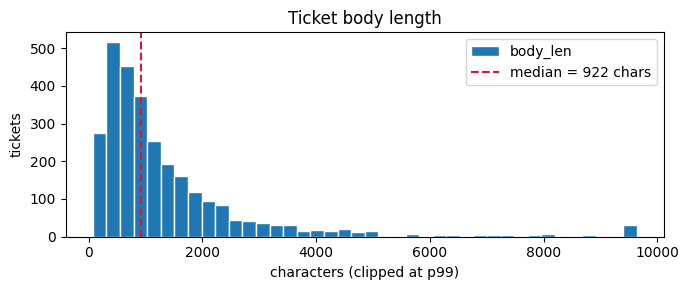

count     2894
mean      1465
std       2067
min         72
25%        517
50%        922
75%       1654
max      28994
Name: body_len, dtype: int64

In [2]:
# 1) Body-length distribution (chars). Right-skewed, so clip the x-axis at the 99th
#    percentile for readability and mark the median. (Cast off the nullable Int64 dtype
#    so float bounds/plotting behave.)
body_len = df['body_len'].astype('float')
p99 = body_len.quantile(0.99)
median = body_len.median()
ax = body_len.clip(upper=p99).plot.hist(bins=40, figsize=(7, 3), edgecolor='white')
ax.axvline(median, color='crimson', ls='--', lw=1.5, label=f'median = {median:,.0f} chars')
ax.set(title='Ticket body length', xlabel='characters (clipped at p99)', ylabel='tickets')
ax.legend()
plt.tight_layout(); plt.show()
body_len.describe().round().astype(int)

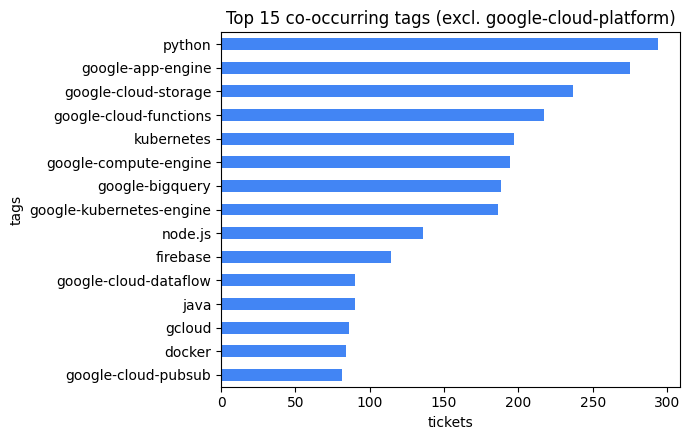

tags
python                      294
google-app-engine           275
google-cloud-storage        237
google-cloud-functions      217
kubernetes                  197
google-compute-engine       194
google-bigquery             188
google-kubernetes-engine    186
node.js                     136
firebase                    114
java                         90
google-cloud-dataflow        90
gcloud                       86
docker                       84
google-cloud-pubsub          81
Name: count, dtype: int64

In [3]:
# 2) Top 15 tags. Every row carries 'google-cloud-platform' (the sampling tag), so drop it
#    to see the GCP *products* that actually dominate the corpus.
tags = df['tags'].str.split('|').explode()
top = tags[tags != CONFIG.sample_tag].value_counts().head(15)
ax = top.sort_values().plot.barh(figsize=(7, 4.5), color='#4285F4')
ax.set(title='Top 15 co-occurring tags (excl. google-cloud-platform)', xlabel='tickets')
plt.tight_layout(); plt.show()
top

overall resolved rate: 43.1%  (1,248 of 2,894)


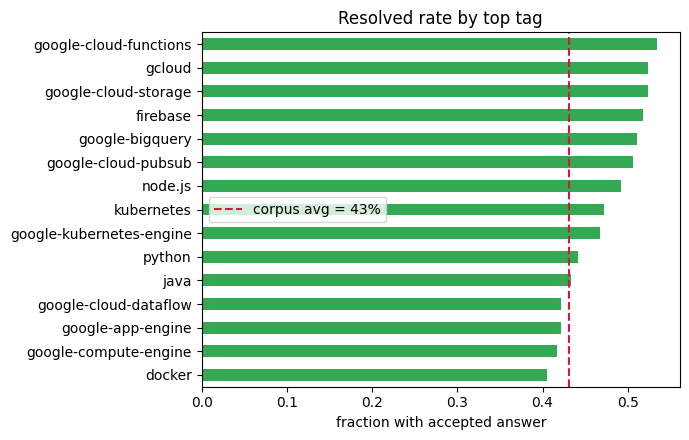

In [4]:
# 3) Resolution rate overall + per top tag. 'Resolved' = has an accepted answer
#    (is_resolved) -> these are the tickets the retrieval graph can actually summarize.
overall = df['is_resolved'].mean()
print(f"overall resolved rate: {overall:.1%}  ({df['is_resolved'].sum():,} of {len(df):,})")

rows = []
for tag in top.index:
    m = df['tags'].str.split('|').apply(lambda ts: tag in ts)
    rows.append((tag, df.loc[m, 'is_resolved'].mean()))
by_tag = (
    __import__('pandas').Series(dict(rows)).sort_values()
)
ax = by_tag.plot.barh(figsize=(7, 4.5), color='#34A853')
ax.axvline(overall, color='crimson', ls='--', lw=1.5, label=f'corpus avg = {overall:.0%}')
ax.set(title='Resolved rate by top tag', xlabel='fraction with accepted answer')
ax.legend()
plt.tight_layout(); plt.show()

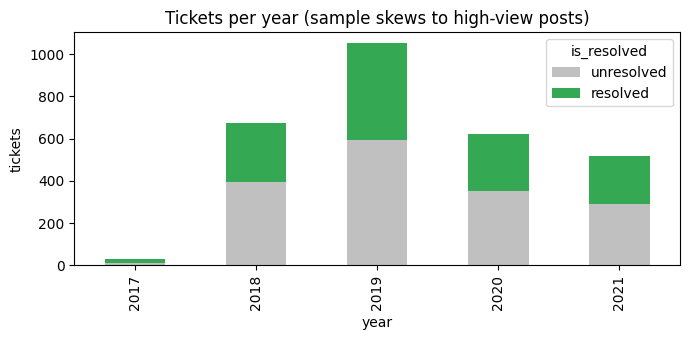

is_resolved,unresolved,resolved
year,,
2017,13,20
2018,393,281
2019,596,455
2020,352,268
2021,292,224


In [5]:
# 4) Time range: tickets per year, split by resolution status.
by_year = (
    df.assign(year=df['creation_date'].dt.year)
      .groupby(['year', 'is_resolved']).size().unstack(fill_value=0)
      .rename(columns={False: 'unresolved', True: 'resolved'})
)
ax = by_year.plot.bar(stacked=True, figsize=(7, 3.5), color=['#C0C0C0', '#34A853'])
ax.set(title='Tickets per year (sample skews to high-view posts)', xlabel='year', ylabel='tickets')
plt.tight_layout(); plt.show()
by_year

## Insights for the report ("data" paragraph)

The working corpus is **2,894 Stack Overflow tickets**, every one tagged `google-cloud-platform`,
sampled by view count from the public dataset and spanning **Dec 2017 - Jan 2021**. Three observations
shape the agent design:

1. **Only ~43% of tickets are "resolved"** (have an accepted answer). The majority carry *no* known-good
   fix, which is exactly the motivation for the retrieval step: the agent must surface the resolved
   minority (~1.25k tickets) as the answerable knowledge base for any new incoming ticket.
2. **Tickets are short and right-skewed** - median body **~915 chars**, mean ~1,465, with a long tail to
   ~29k. The bulk sit comfortably under the NL API single-unit (~1,000 chars) and Gemini context
   budgets, so per-ticket extraction and summarization stay within the free tier.
3. **The corpus is genuinely GCP-product-centric** (App Engine, Cloud Storage, Cloud Functions,
   BigQuery, GKE), and resolution rate tracks product type: serverless tags resolve best
   (Cloud Functions ~54%, Cloud Storage ~52%) while infra tags lag (Compute Engine ~42%, GKE ~47%) -
   a useful prior for routing and for setting expectations on retrieval coverage by domain.

*Caveat:* the sample is ordered by `view_count` (high-signal tickets), so the per-year counts reflect
the sampling cut, not organic Stack Overflow volume.